regiones y fronteras

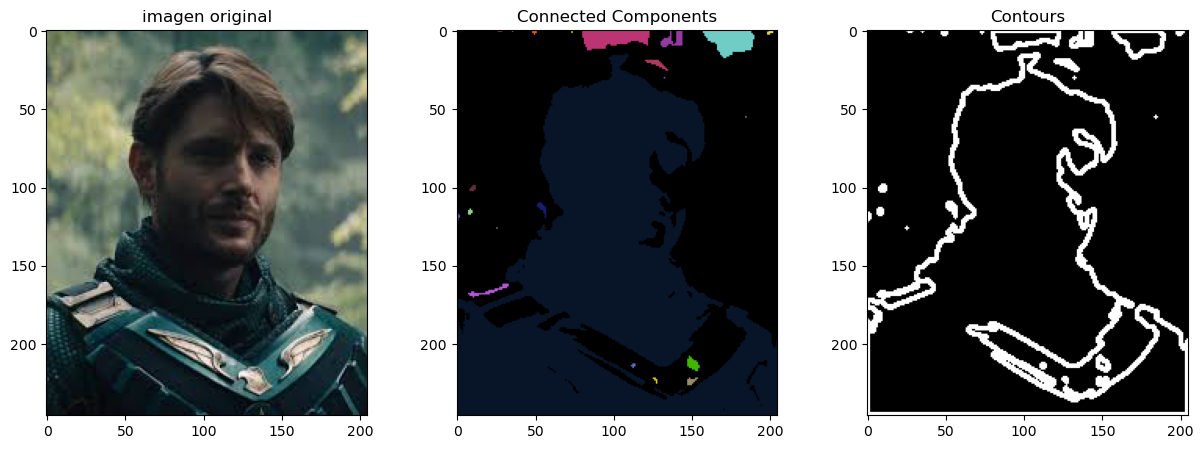

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img= cv2.imread('soldierboy.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur= cv2.GaussianBlur(gray, (3, 3), 0)
_,binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

Nnum_l, label= cv2.connectedComponents(binary)
color=np.random.randint(0, 255, size=(Nnum_l, 3), dtype=np.uint8)

color[0] = [0, 0, 0]
colorear=color[label]


contornos,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin= cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('imagen original')
plt.subplot(132)
plt.imshow(colorear)
plt.title('Connected Components')
plt.subplot(133)
plt.imshow(contorno_fin, cmap='gray')
plt.title('Contours')
plt.show()


conteo

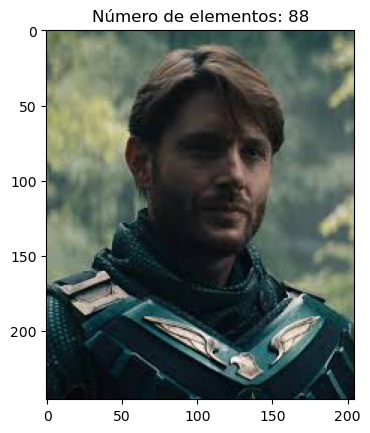

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binary=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

    e_img=measure.label(binary, connectivity=2) # 2- conectividad es de 4 1- conectividad es de 8
    num_obj=np.max(e_img)
    return num_obj
imagen=cv2.imread('soldierboy.jpg')
conteo=contar_elementos(imagen)

plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title(f'Número de elementos: {conteo}')
plt.show()

practica

Total de regiones detectadas (skimage): 9
Region 1: 24970 pixeles , Color RGB: (95, 179, 61)
Region 2: 60 pixeles , Color RGB: (234, 203, 92)
Region 3: 129 pixeles , Color RGB: (3, 98, 243)
Region 4: 442 pixeles , Color RGB: (14, 149, 245)
Region 5: 63 pixeles , Color RGB: (46, 106, 244)
Region 6: 103 pixeles , Color RGB: (99, 187, 71)
Region 7: 7 pixeles , Color RGB: (212, 153, 199)
Region 8: 7 pixeles , Color RGB: (188, 174, 65)
Region 9: 1 pixeles , Color RGB: (153, 20, 44)


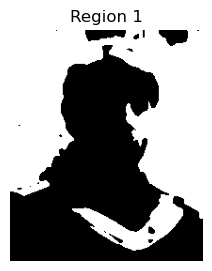

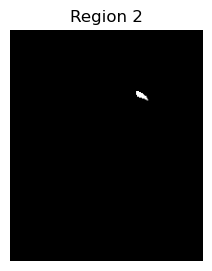

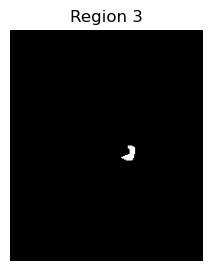

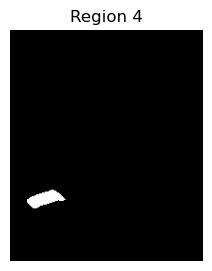

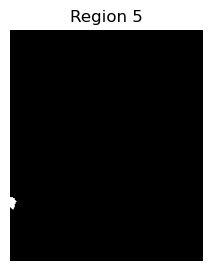

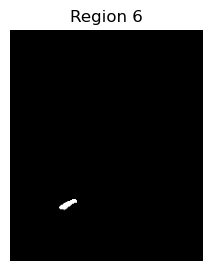

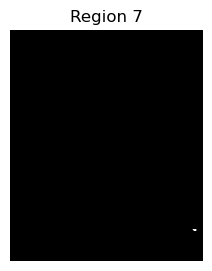

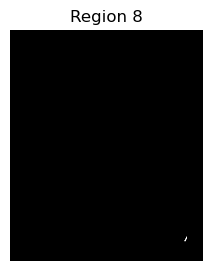

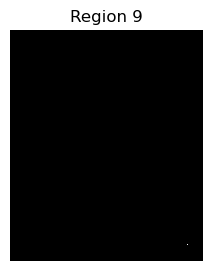

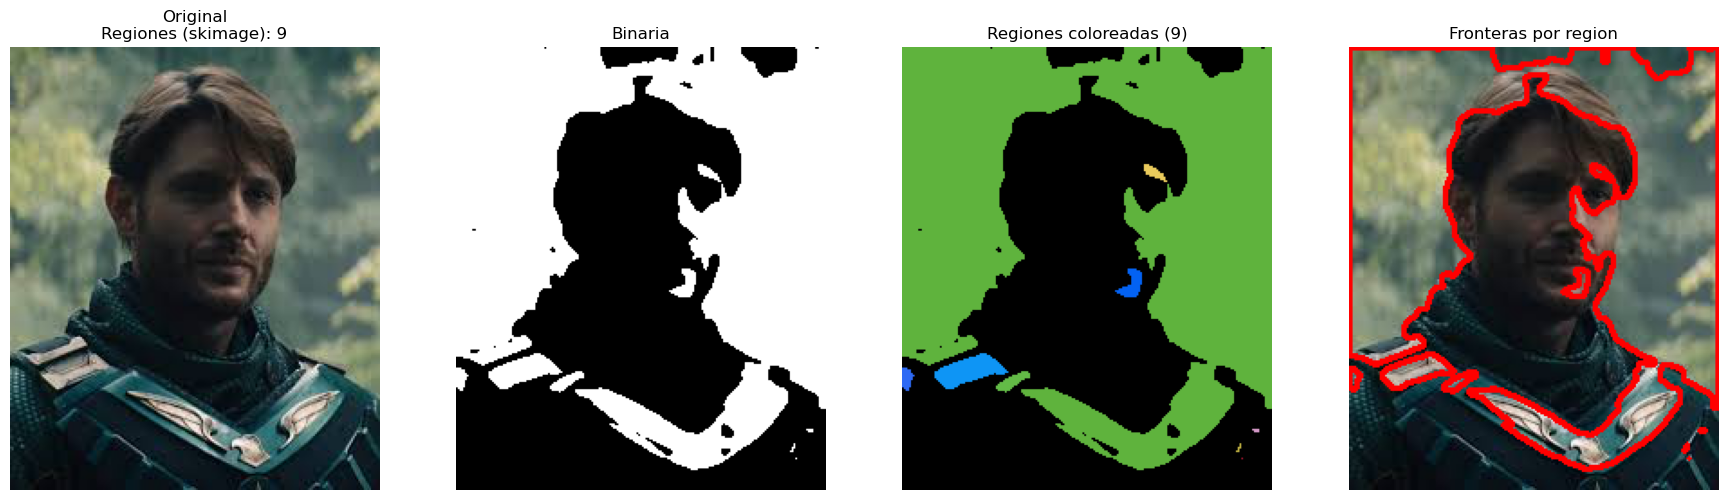

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('soldierboy.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


conteo = int(np.max(measure.label(binary, connectivity=2)))
num_l, labels = cv2.connectedComponents(binary)

np.random.seed(42)
colors = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
colors[0] = [0, 0, 0]  
colorear = colors[labels]  

contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
fronteras = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
cv2.drawContours(fronteras, contornos, -1, (255, 0, 0), 2)  

print(f'Total de regiones detectadas (skimage): {conteo}')
for i in range(1, num_l):
    pixeles = int(np.sum(labels == i))
    c = colors[i]  # ahora es RGB
    print(f'Region {i}: {pixeles} pixeles , Color RGB: ({c[0]}, {c[1]}, {c[2]})')

for i in range(1, num_l):
    mask = (labels == i).astype(np.uint8) * 255
    plt.figure(figsize=(3, 3))
    plt.imshow(mask, cmap="gray")
    plt.title(f"Region {i}")
    plt.axis("off")
plt.show()
fig, axs = plt.subplots(1, 4, figsize=(18, 5))
axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0].set_title(f'Original\nRegiones (skimage): {conteo}')
axs[0].axis('off')

axs[1].imshow(binary, cmap='gray')
axs[1].set_title('Binaria')
axs[1].axis('off')

axs[2].imshow(colorear)
axs[2].set_title(f'Regiones coloreadas ({num_l - 1})')
axs[2].axis('off')

axs[3].imshow(fronteras)
axs[3].set_title('Fronteras por region')
axs[3].axis('off')

plt.tight_layout()
plt.show()